In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [18]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.0 MB/s eta 0:00:00


In [ ]:
import shutil

shutil.make_archive(
    "/content/drive/MyDrive/final-year-research/datasets/facemask_dataset",
    "zip",
    "/content/drive/MyDrive/final-year-research/transformed_datasets/faceblur_dataset"
)

print("Dataset zipped and saved to Drive")

KeyboardInterrupt: 

In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/datasets/facemask_dataset.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/facemask_dataset.zip")
print("Copied zip to Colab VM")

In [ ]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/facemask_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"

SRC_FOLDER = f"{PROJECT_DIR}/datasets/facemask_dataset"
DEST_FOLDER = f"{WORK_DIR}/facemask_dataset"

os.makedirs(WORK_DIR, exist_ok=True)
if os.path.exists(DEST_FOLDER):
    shutil.rmtree(DEST_FOLDER)   # delete existing folder

shutil.copytree(SRC_FOLDER, DEST_FOLDER)

print("Folder copied successfully")

Folder copied successfully


In [ ]:
import os
import shutil

if os.path.exists(DEST_FOLDER):
    shutil.rmtree(DEST_FOLDER)   # delete existing folder

shutil.copytree(SRC_FOLDER, DEST_FOLDER)

print("Folder copied successfully")

NameError: name 'DEST_FOLDER' is not defined

In [ ]:
!ls /content/final-year-research/facemask_dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [ ]:
!find /content/final-year-research -maxdepth 3 -type d

/content/final-year-research
/content/final-year-research/facemask_dataset
/content/final-year-research/facemask_dataset/train
/content/final-year-research/facemask_dataset/train/labels
/content/final-year-research/facemask_dataset/train/images
/content/final-year-research/facemask_dataset/valid
/content/final-year-research/facemask_dataset/valid/labels
/content/final-year-research/facemask_dataset/valid/images


In [ ]:
import glob

ROOT = "/content/final-year-research/facemask_dataset"

print("train images:", len(glob.glob(ROOT + "/train/images/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/images/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))

train images: 10098
train labels: 10098
valid images: 3284
valid labels: 3284


In [ ]:
import yaml

yaml_path = "/content/final-year-research/WilderPerson_colab.yaml"

data = {
    "path": "/content/final-year-research/facemask_dataset",
    "train": "/content/final-year-research/facemask_dataset/train/images",
    "val": "/content/final-year-research/facemask_dataset/valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("YAML fixed! Now defining 2 classes (0 and 1).")

YAML fixed! Now defining 2 classes (0 and 1).


In [ ]:
!yolo detect train \
  model=yolov8s.pt \
  data="/content/final-year-research/WilderPerson_colab.yaml" \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  device=0 \
  patience=20 \
  project="/content/drive/MyDrive/final-year-research/runs" \
  name="wilderperson_facemask_research_v1"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

In [ ]:
!yolo detect train \
  model="/content/drive/MyDrive/final-year-research/runs/wilderperson_facemask_research_v1/weights/last.pt" \
  data="/content/final-year-research/WilderPerson_colab.yaml" \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  device=0 \
  patience=20 \
  project="/content/drive/MyDrive/final-year-research/runs" \
  name="wilderperson_facemask_research_v1" \
  resume=True

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/final-year-research/runs/wilderperson_facemask_research_v1/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

Testing


Selected Image: 019699_jpg.rf.8a43df339d74162d5a3f935ab132944a.jpg

image 1/1 /content/final-year-research/facemask_dataset/valid/images/019699_jpg.rf.8a43df339d74162d5a3f935ab132944a.jpg: 640x640 15 pedestrians, 17 others, 16.2ms
Speed: 2.4ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


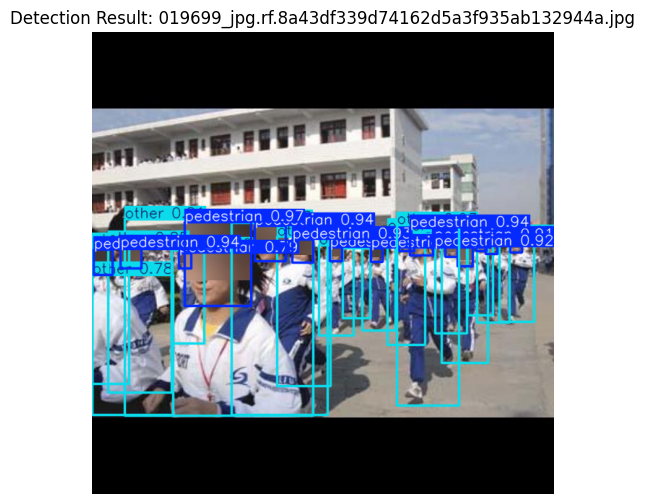

In [ ]:
 from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import random

# Load your trained model
model = YOLO("/content/drive/MyDrive/final-year-research/runs/wilderperson_facemask_research_v1/weights/best.pt")

# Folder containing images
image_dir = "/content/final-year-research/facemask_dataset/valid/images"

# Get all image files
image_list = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

# Randomly select one image
random_image = random.choice(image_list)
image_path = os.path.join(image_dir, random_image)

print("Selected Image:", random_image)

# Run prediction
results = model.predict(
    source=image_path,
    conf=0.25,
    save=False
)

# Get plotted result
result_img = results[0].plot()

# Convert BGR to RGB
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(result_img)
plt.axis("off")
plt.title(f"Detection Result: {random_image}")
plt.show()

In [7]:
RUN_DIR = "/content/drive/MyDrive/final-year-research/runs/wilderperson_facemask_research_v1"

Showing: BoxPR_curve.png


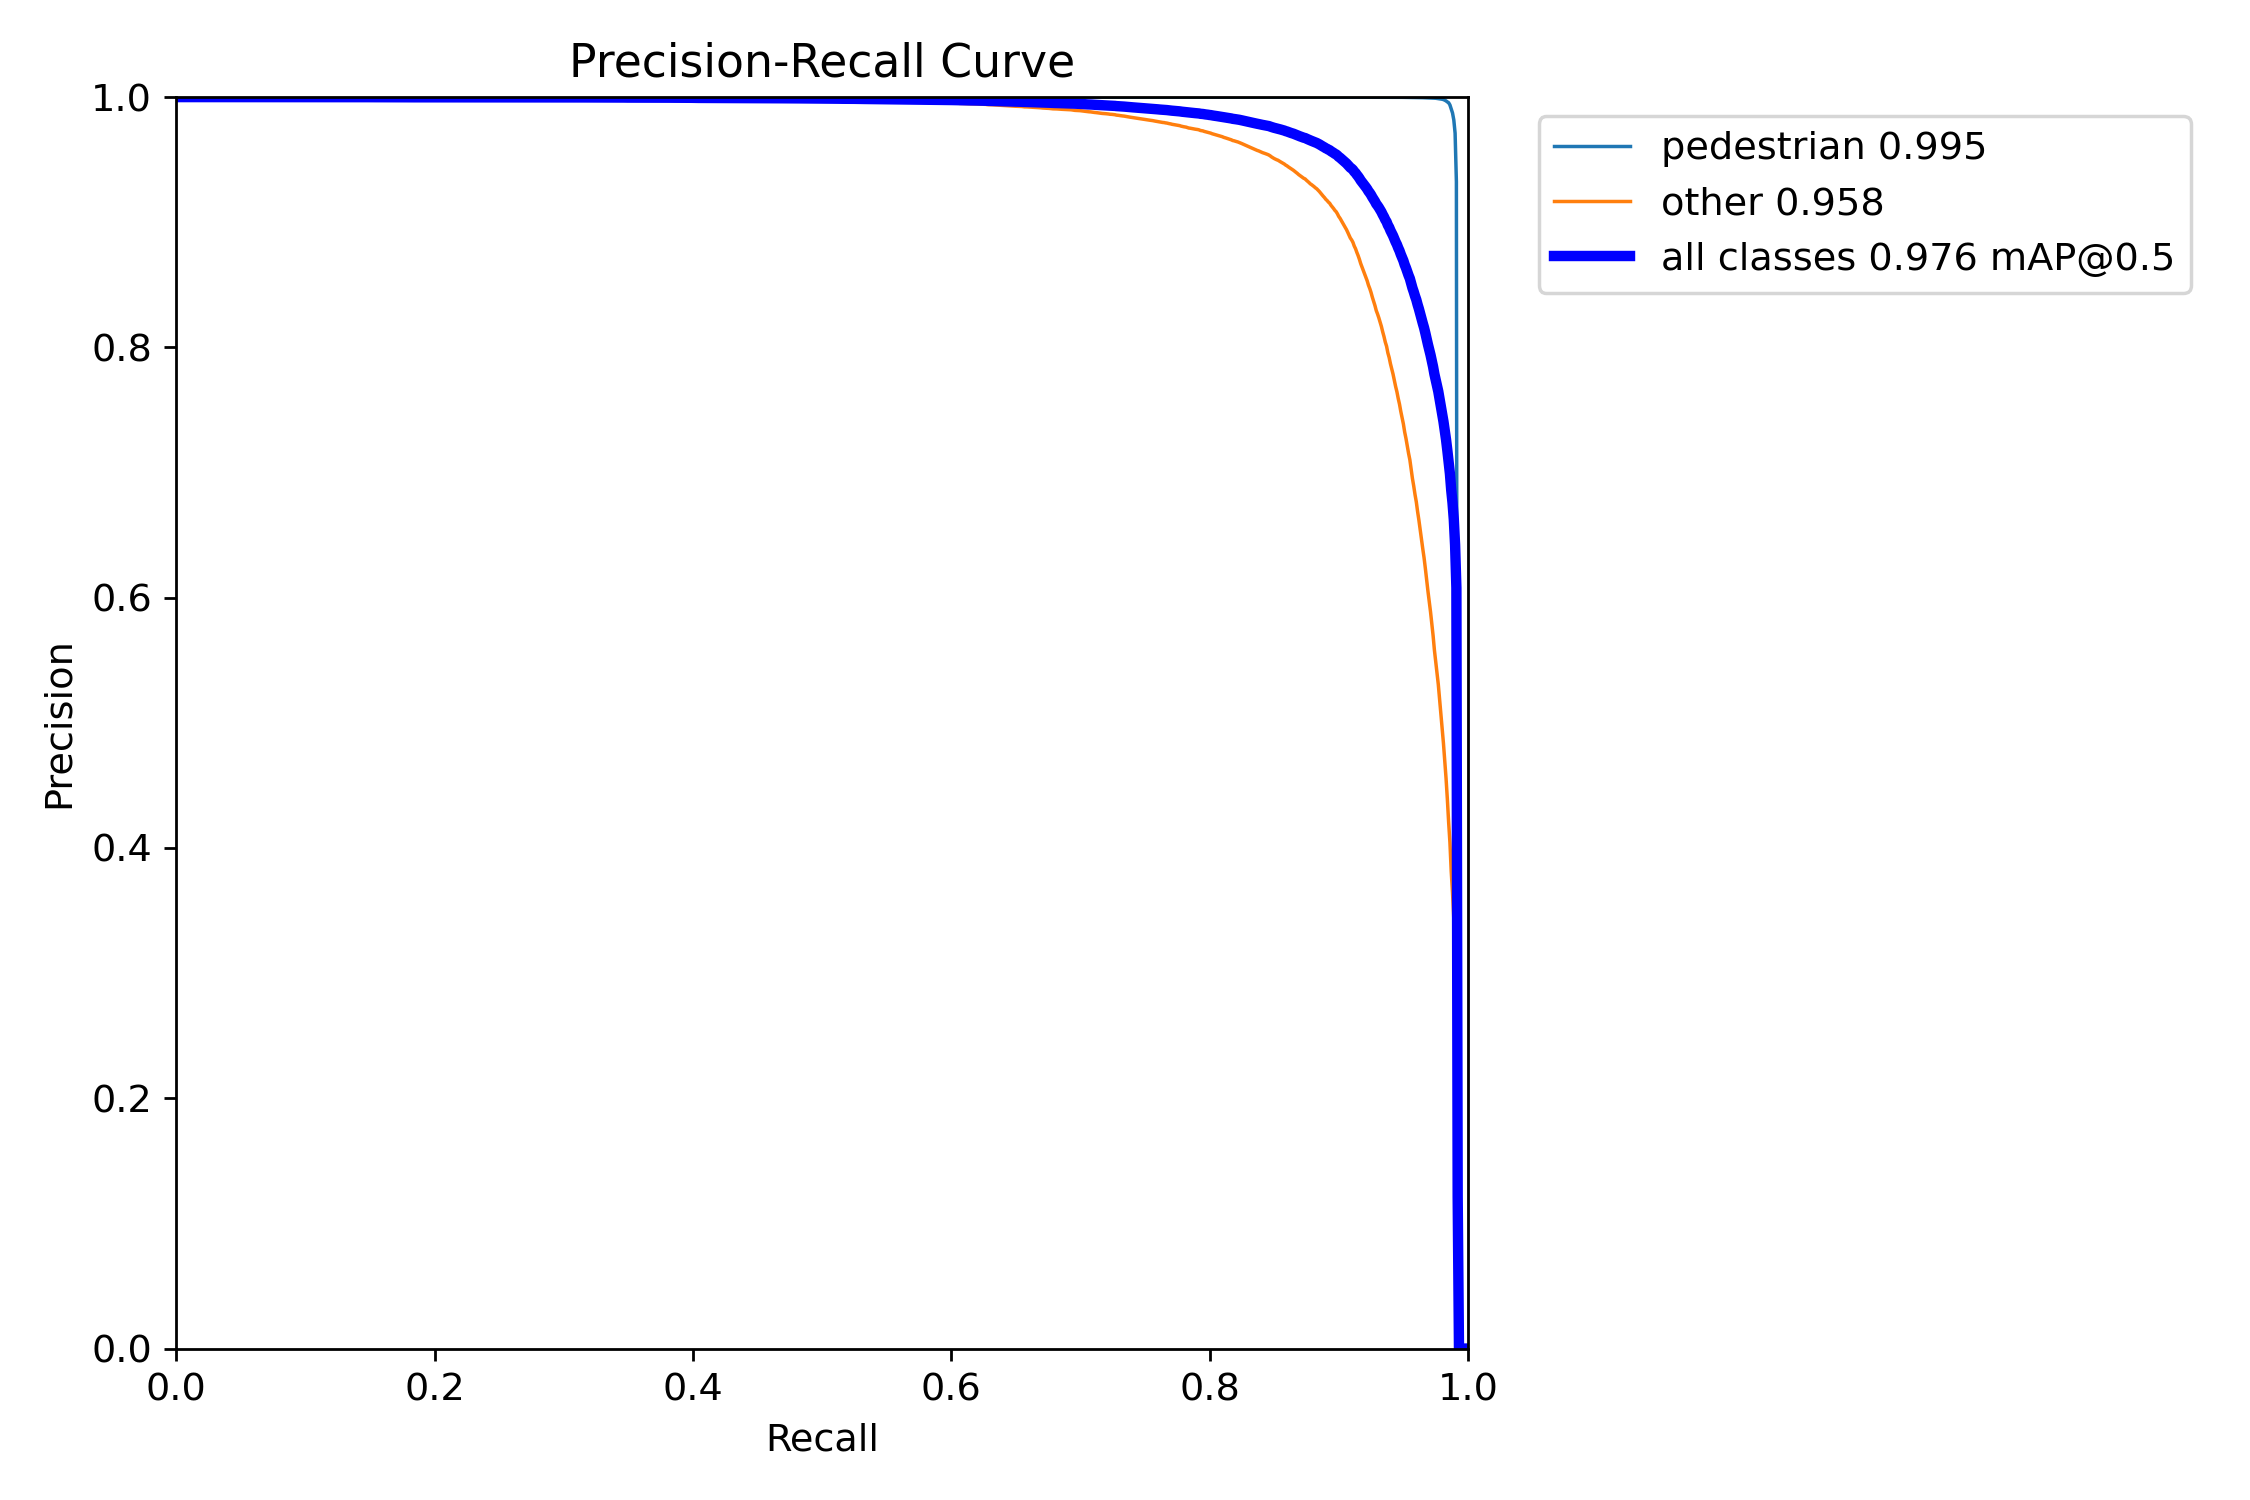

Showing: BoxF1_curve.png


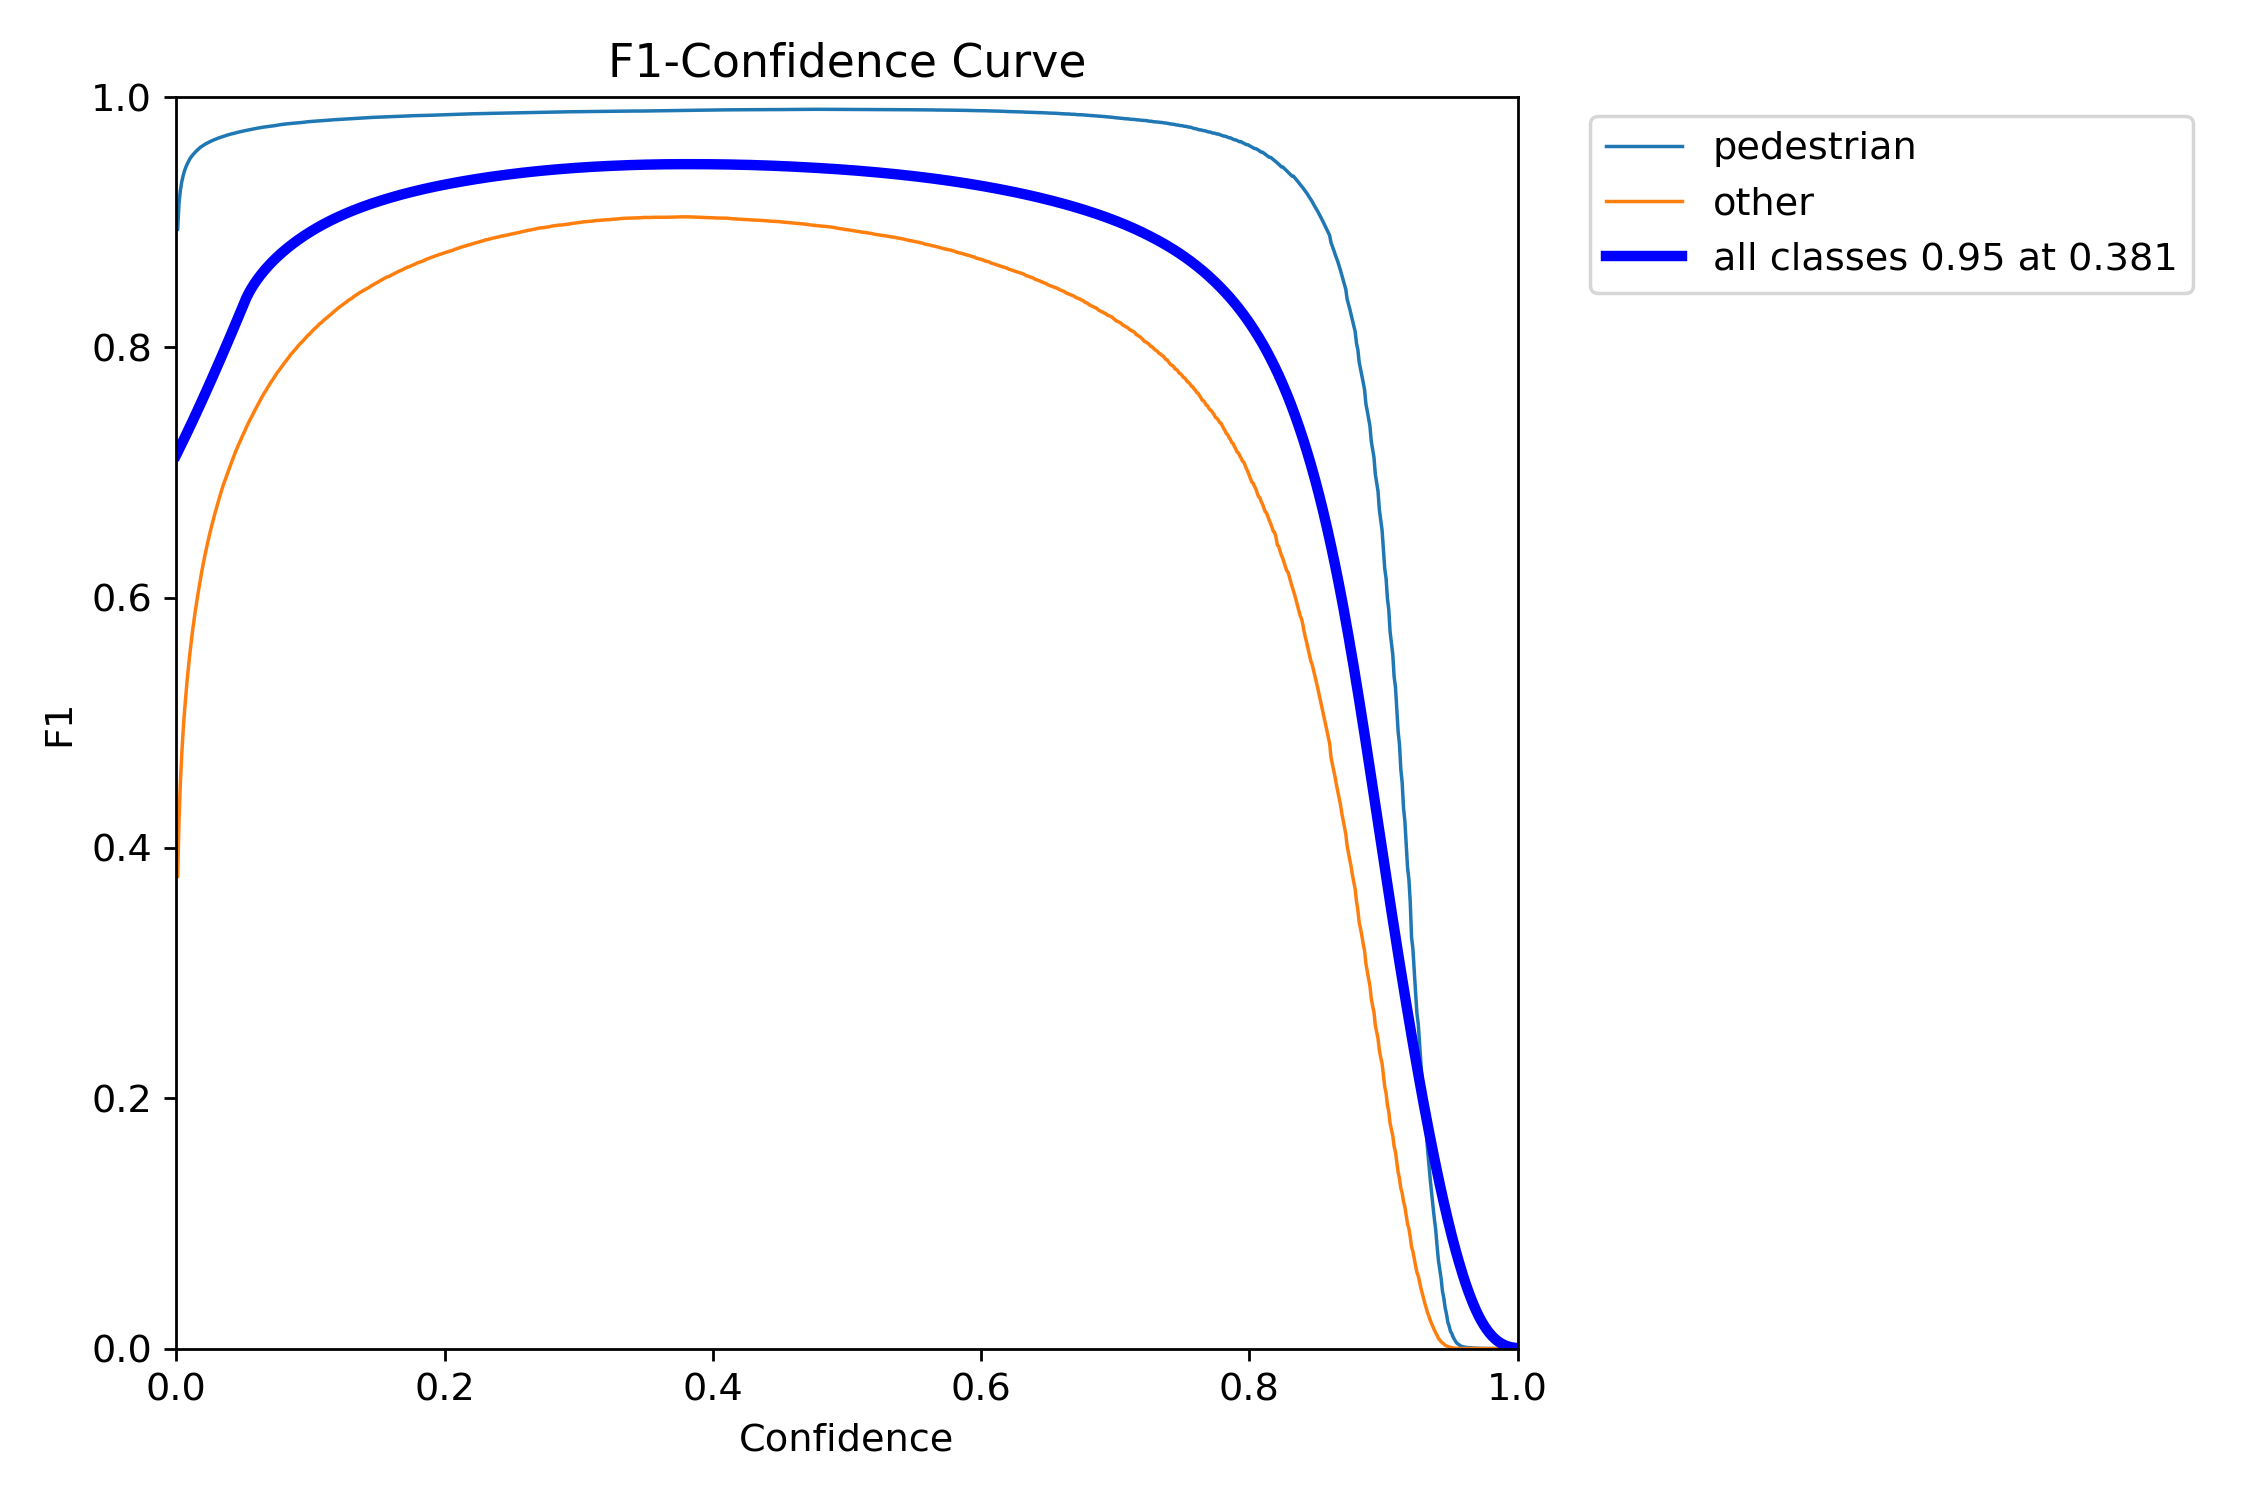

Showing: BoxP_curve.png


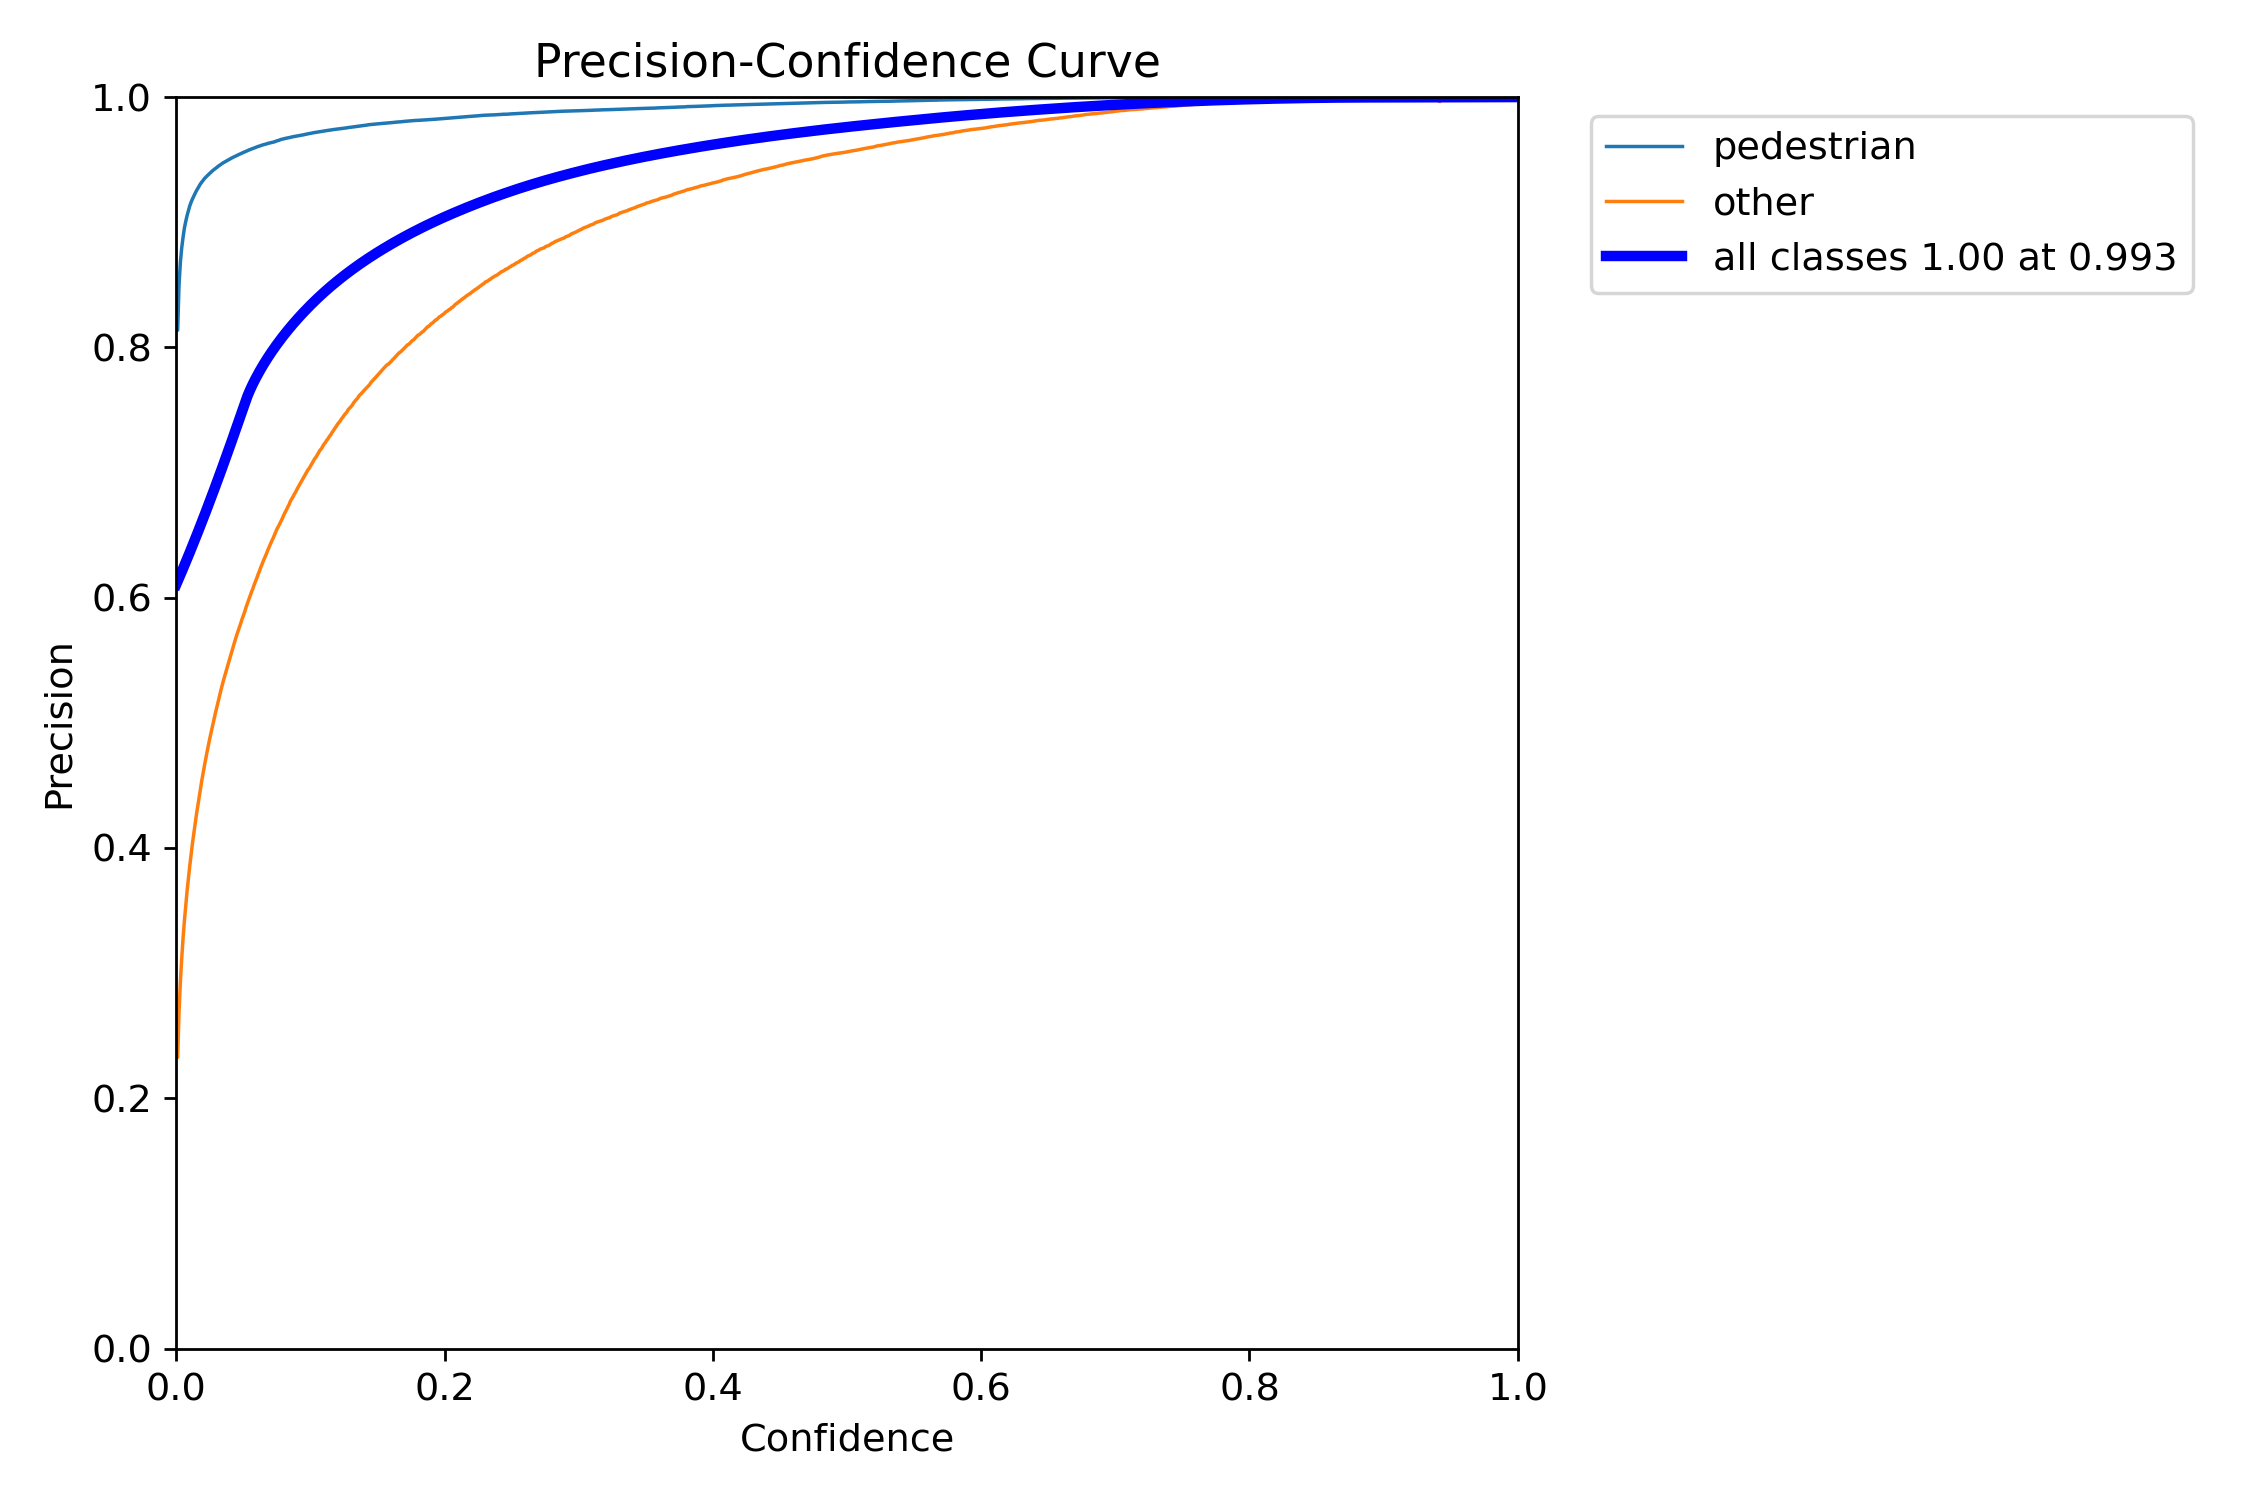

Showing: BoxR_curve.png


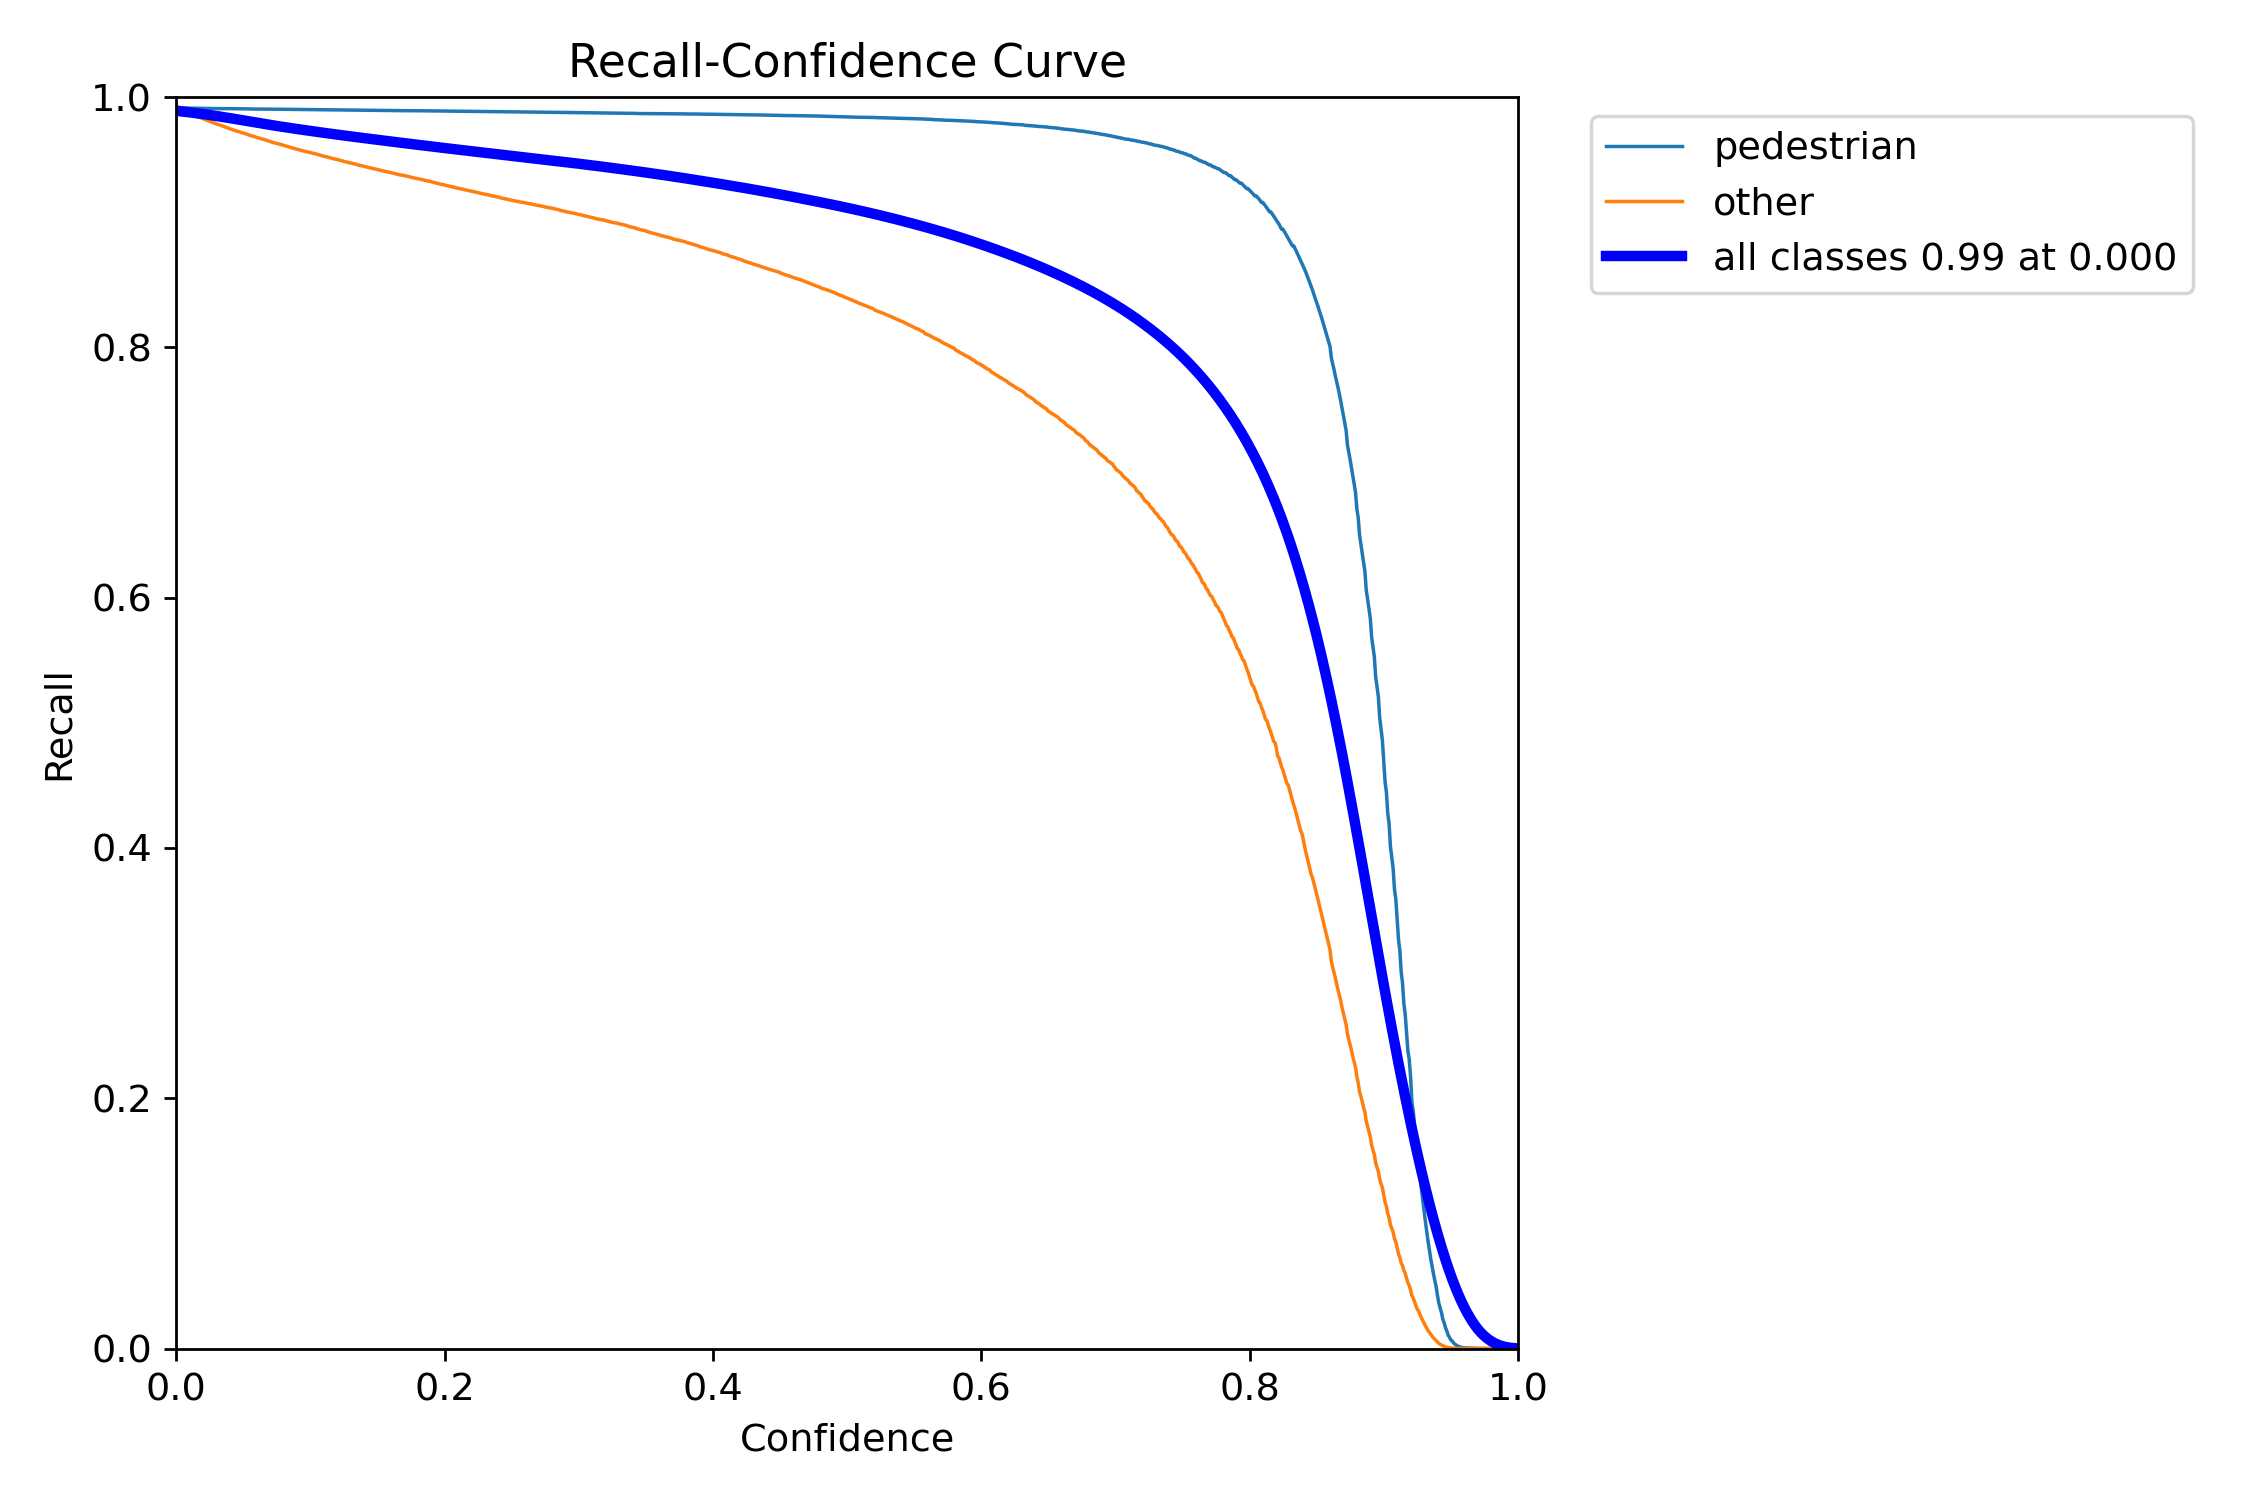

Showing: confusion_matrix_normalized.png


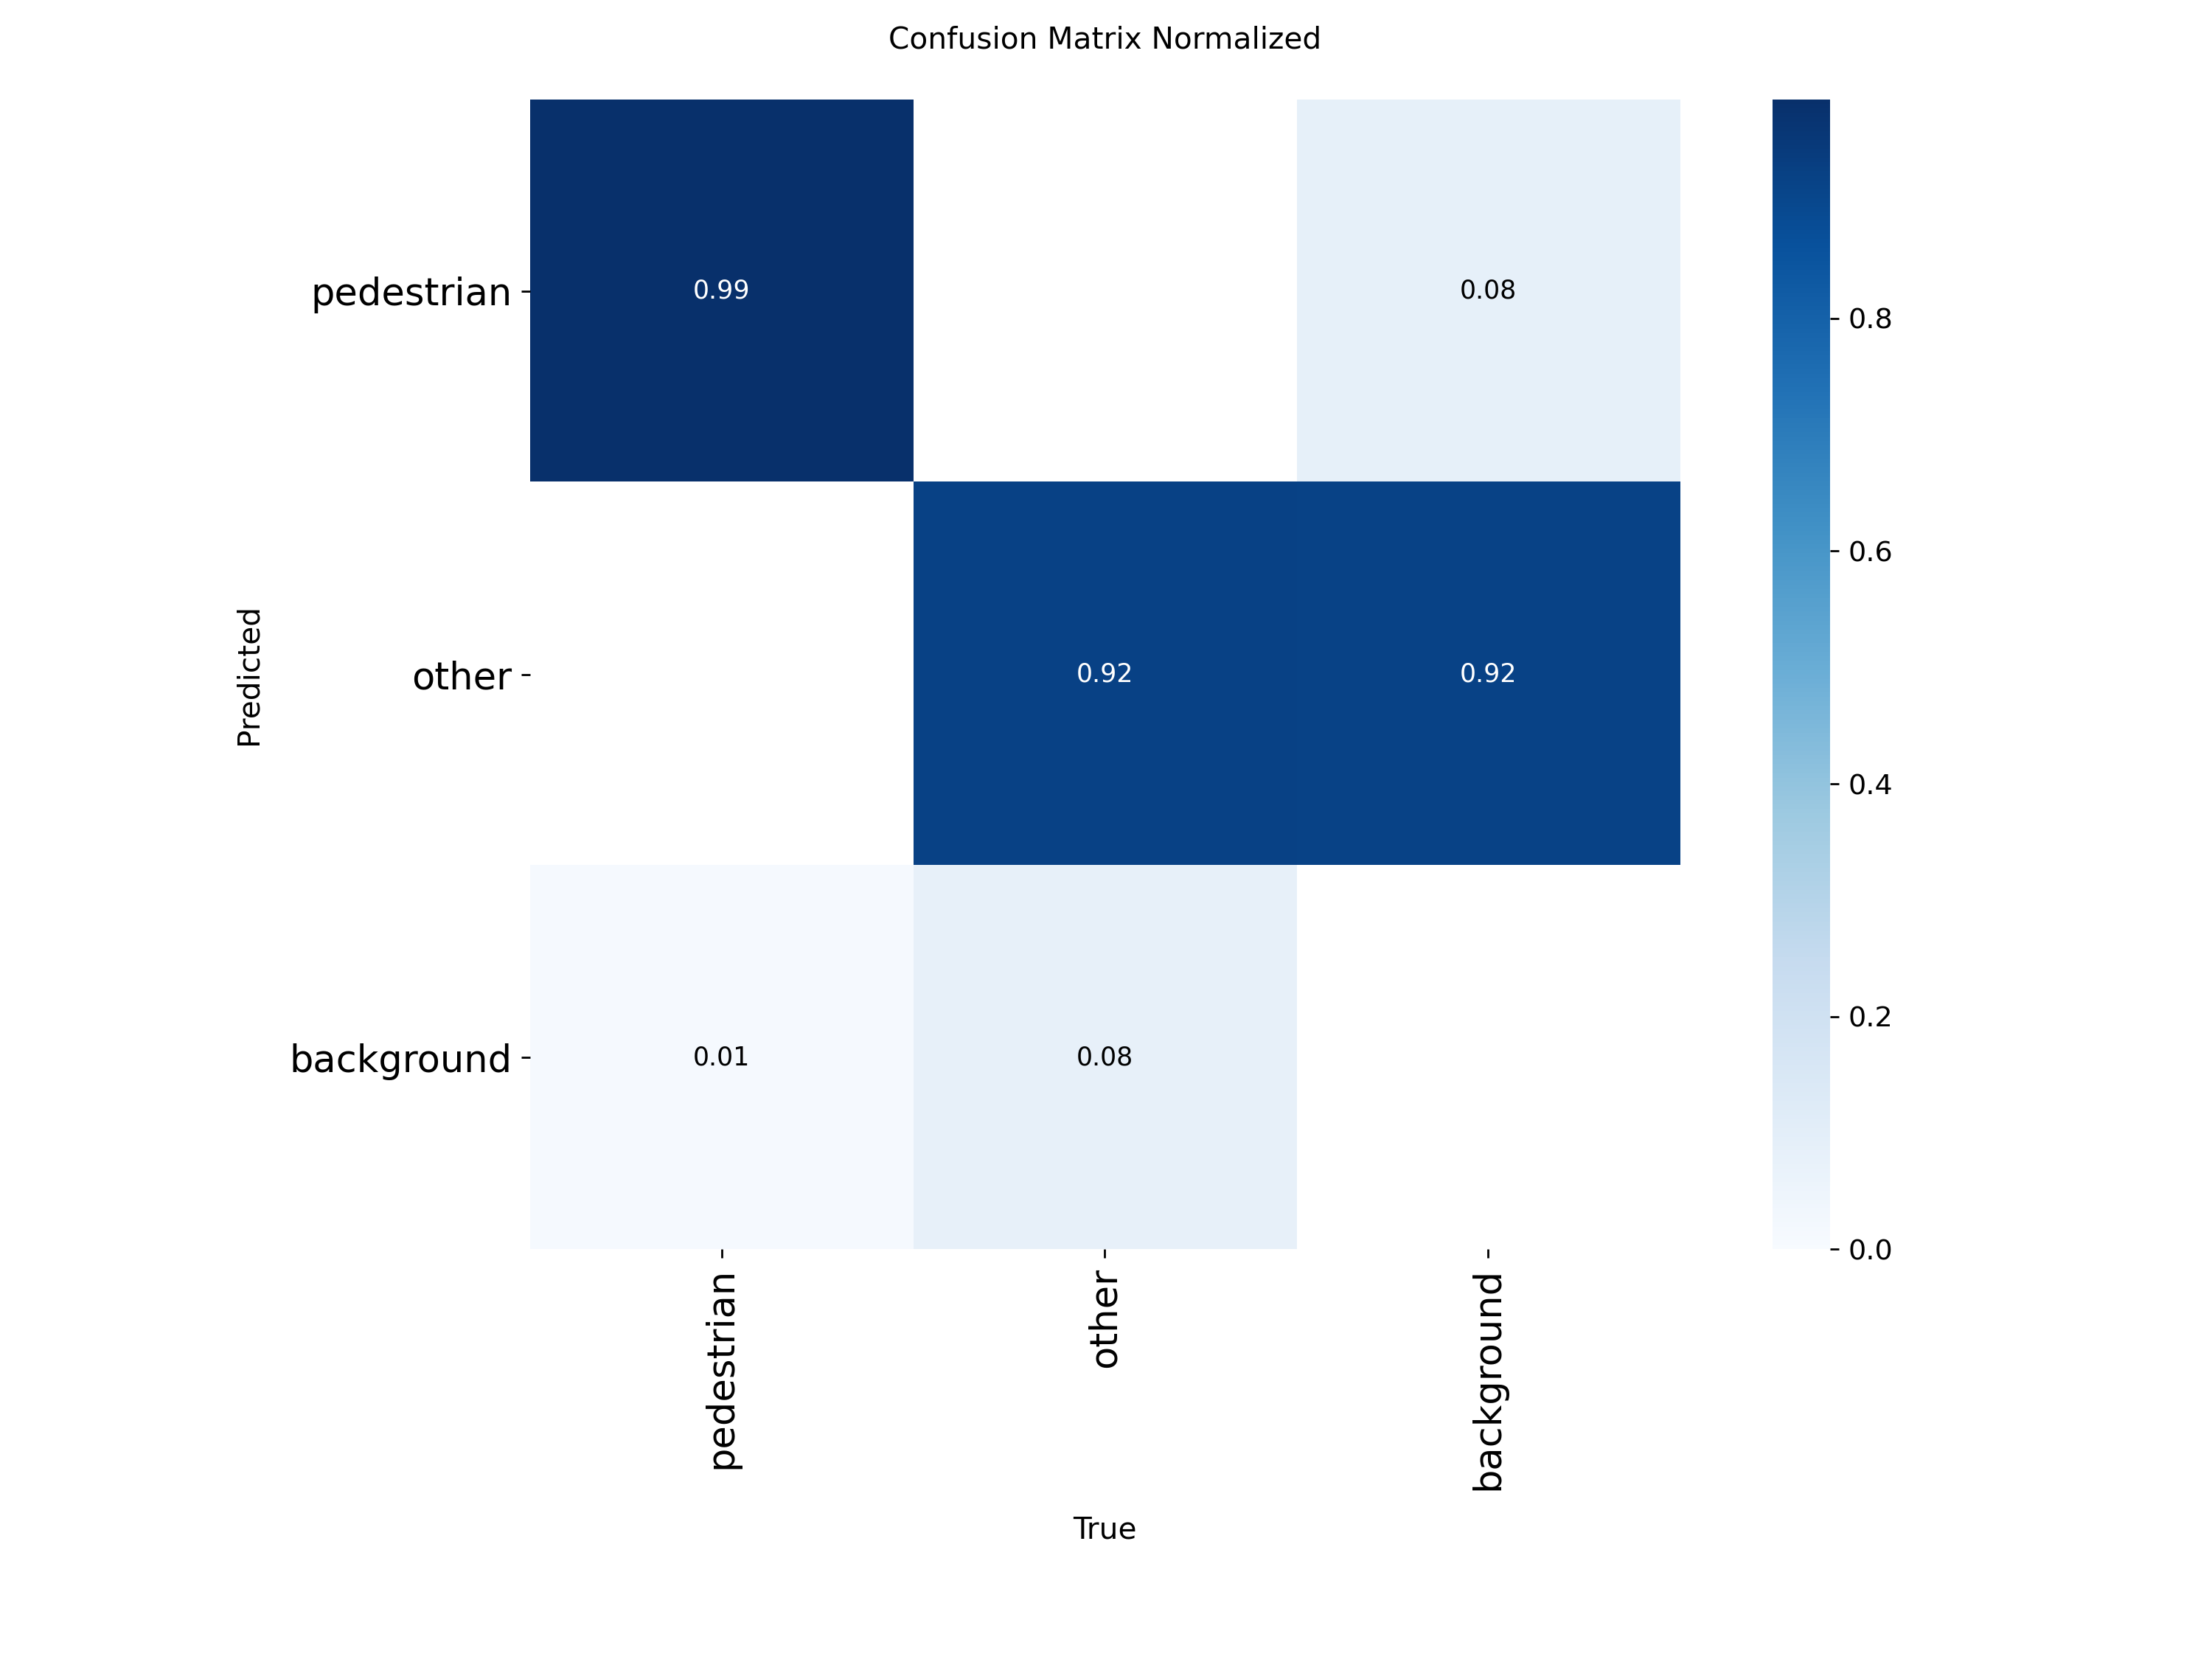

Showing: confusion_matrix.png


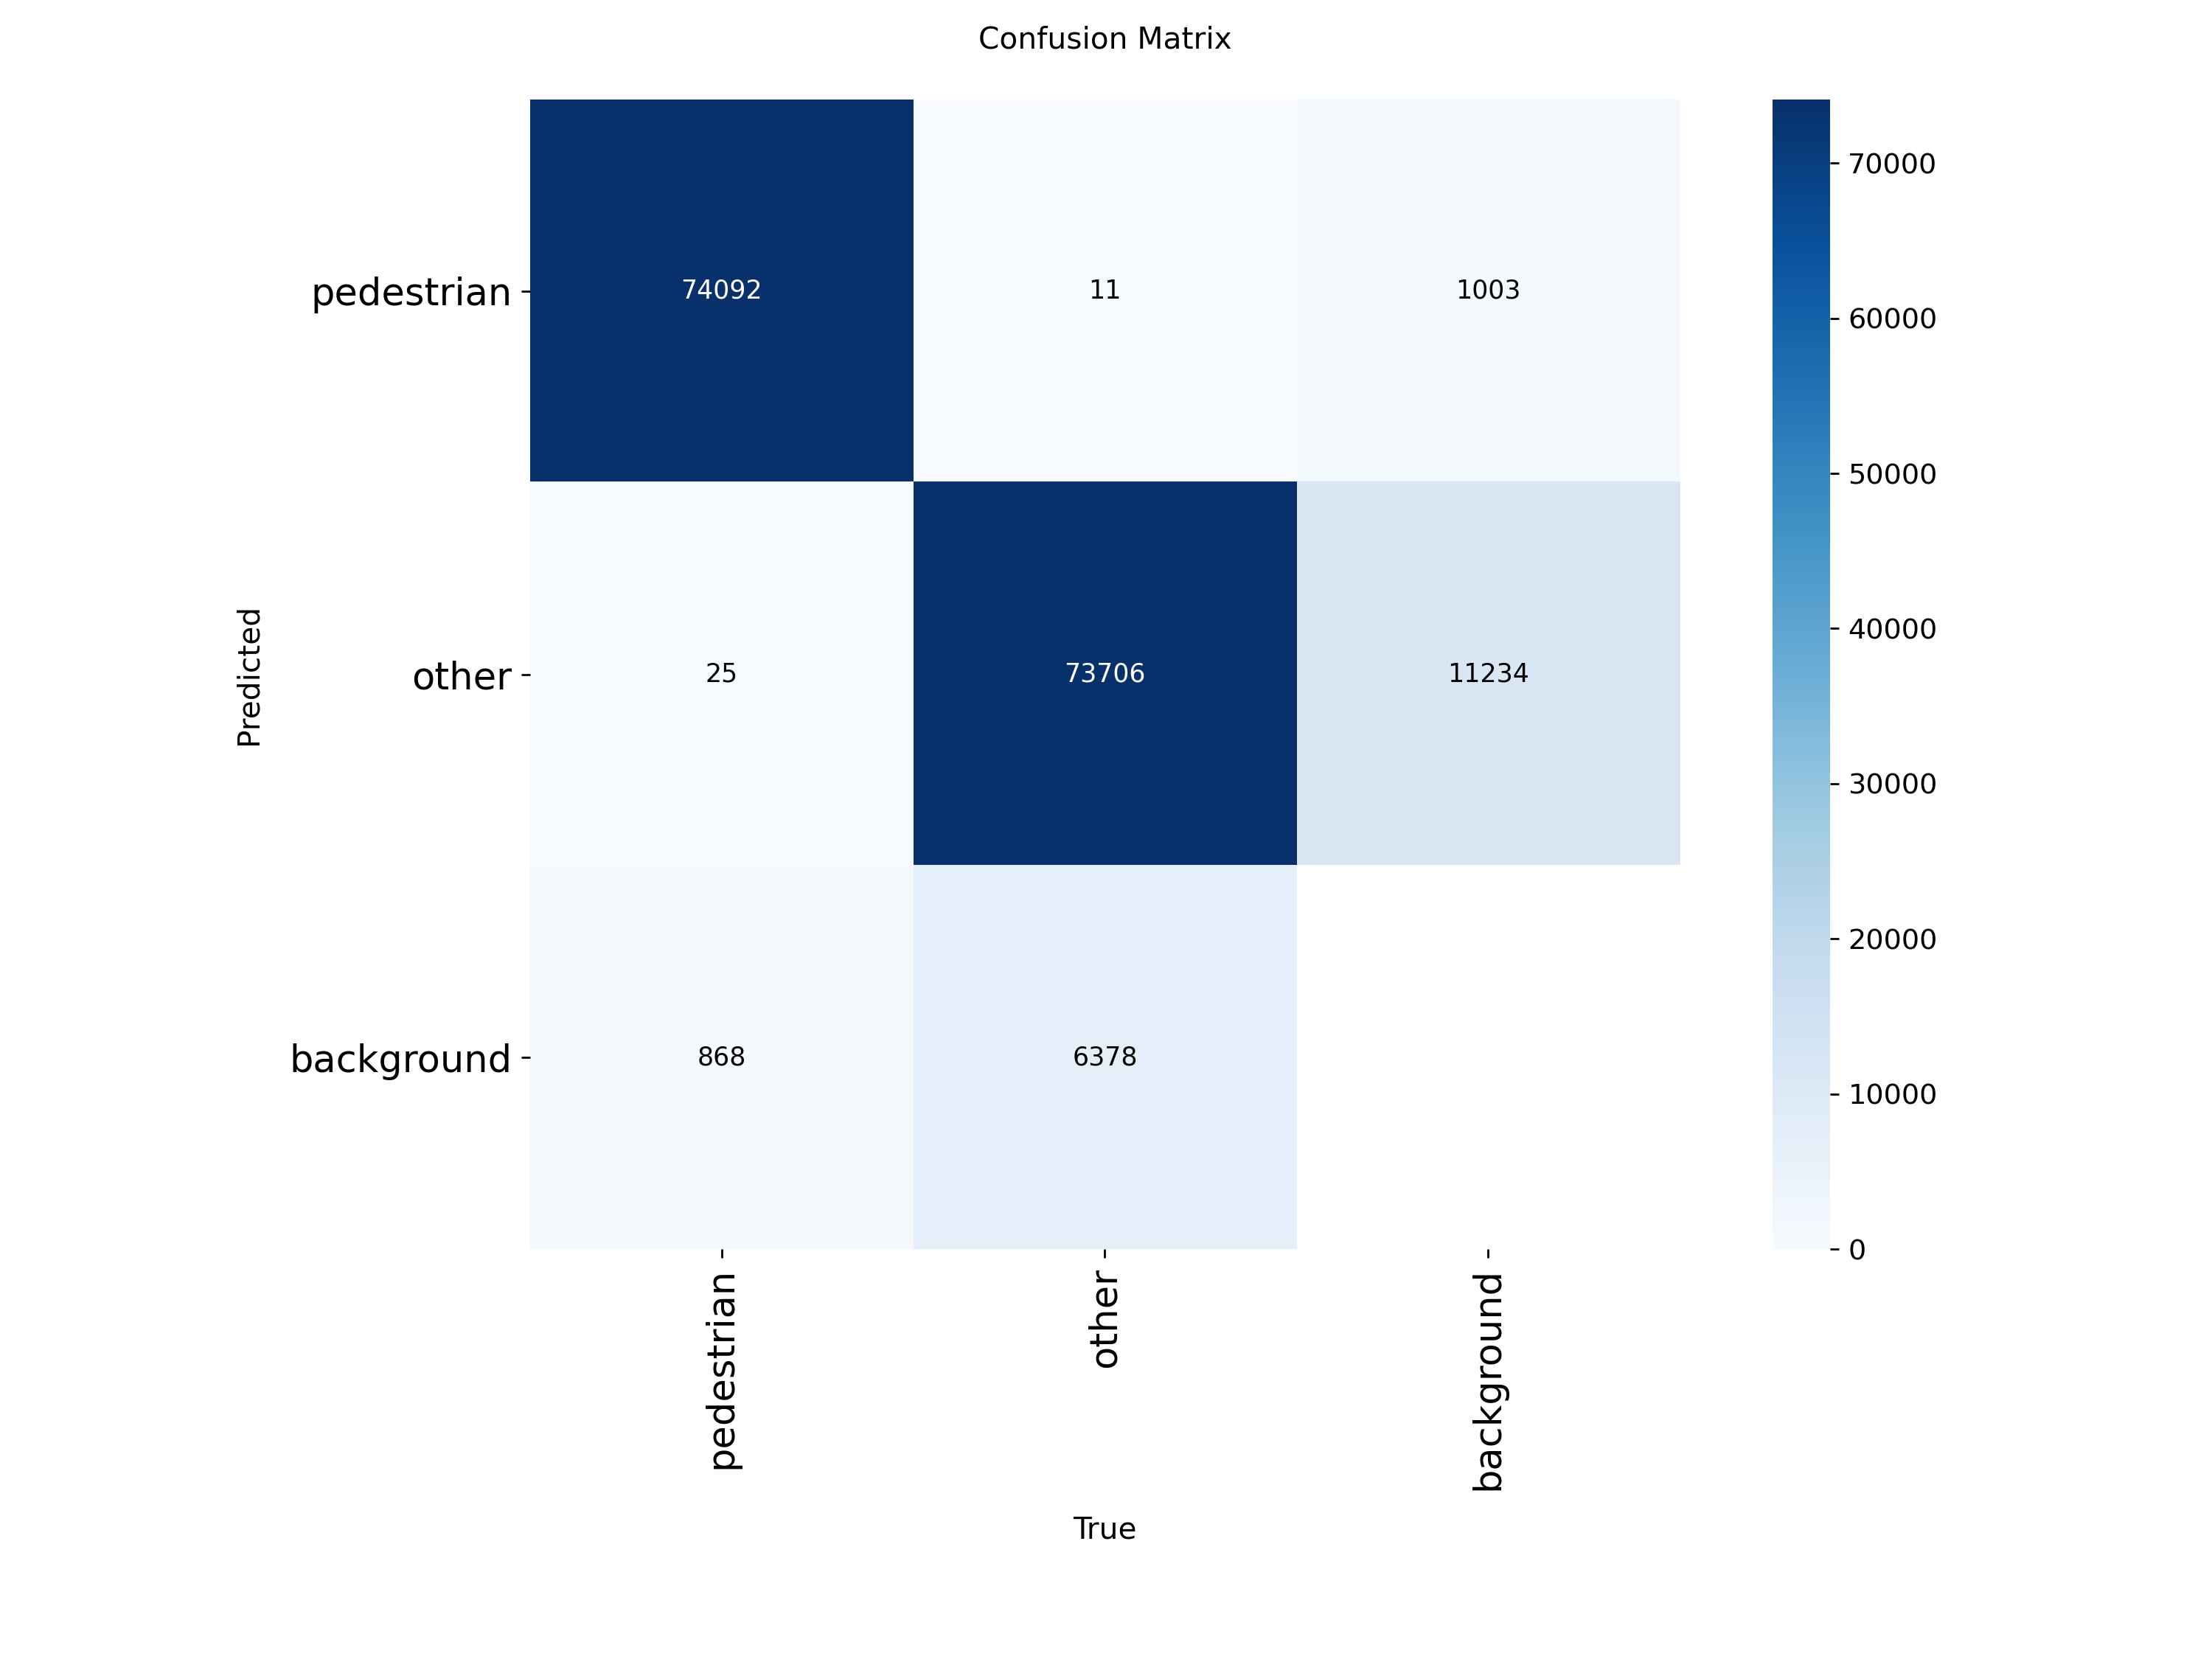

Showing: results.png


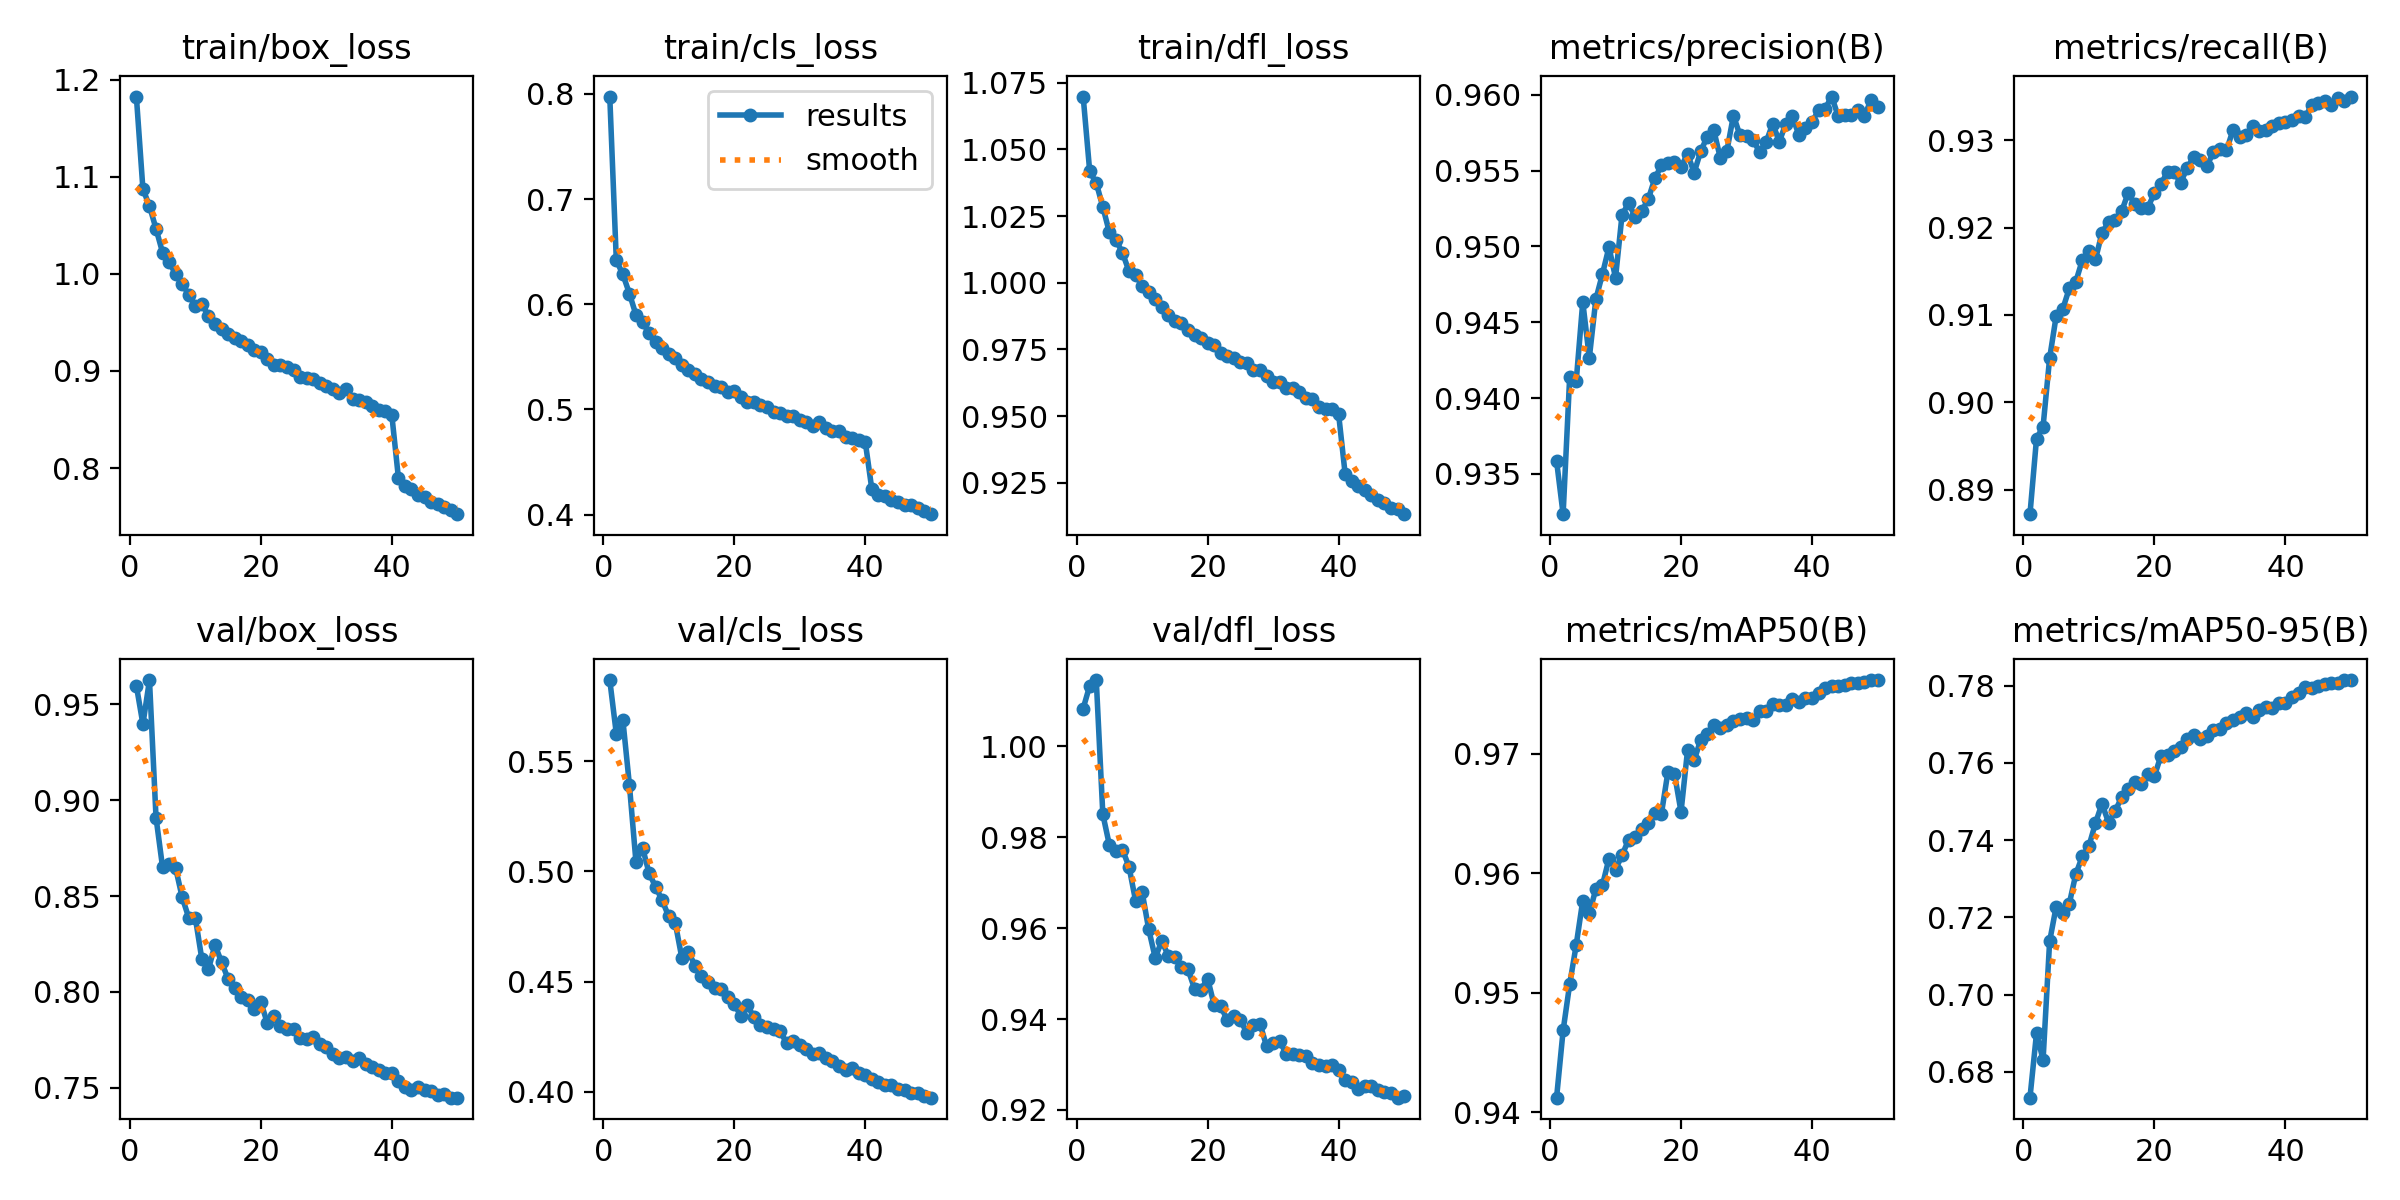

In [8]:
from IPython.display import Image, display
import os

for file in os.listdir(RUN_DIR):
    if file.endswith(".png"):
        print("Showing:", file)
        display(Image(filename=os.path.join(RUN_DIR, file)))

In [10]:
import pandas as pd

csv_path = os.path.join(RUN_DIR, "results.csv")
df = pd.read_csv(csv_path)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,268.787,1.18267,0.79745,1.06977,0.93585,0.88718,0.94123,0.67333,0.95977,0.58683,1.00831,0.000555,0.000555,0.000555
1,2,530.404,1.08741,0.64169,1.04169,0.93234,0.89583,0.94685,0.69004,0.93969,0.56245,1.01333,0.001088,0.001088,0.001088
2,3,791.485,1.06995,0.62840,1.03737,0.94137,0.89720,0.95071,0.68310,0.96271,0.56873,1.01457,0.001600,0.001600,0.001600
3,4,1050.220,1.04651,0.61011,1.02841,0.94112,0.90504,0.95401,0.71380,0.89099,0.53922,0.98506,0.001568,0.001568,0.001568
4,5,1313.300,1.02198,0.58989,1.01890,0.94634,0.90987,0.95772,0.72278,0.86502,0.50427,0.97828,0.001535,0.001535,0.001535


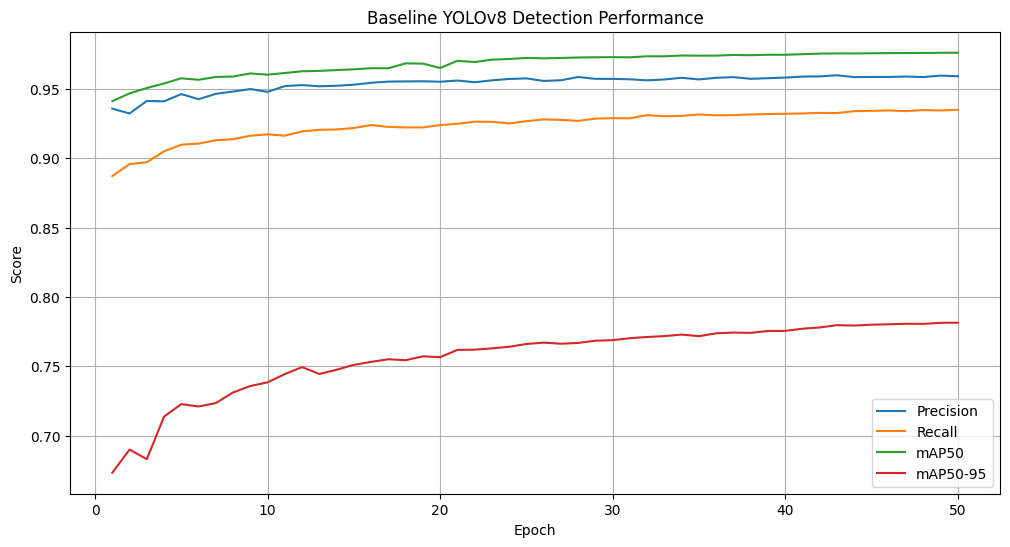

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Baseline YOLOv8 Detection Performance")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]

import pandas as pd

summary = pd.DataFrame([{
    "Experiment": "Baseline",
    "Dataset": "Original CityPersons",
    "Model": "YOLOv8n",
    "Epochs": 50,
    "Best Epoch": int(best_row["epoch"]),
    "Precision": round(best_row["metrics/precision(B)"],3),
    "Recall": round(best_row["metrics/recall(B)"],3),
    "mAP50": round(best_row["metrics/mAP50(B)"],3),
    "mAP50-95": round(best_row["metrics/mAP50-95(B)"],3),
    "Hardware": "Tesla T4 GPU"
}])

summary

,Experiment,Dataset,Model,Epochs,Best Epoch,Precision,Recall,mAP50,mAP50-95,Hardware
0,Baseline,Original CityPersons,YOLOv8n,50,50,0.959,0.935,0.976,0.781,Tesla T4 GPU


Testing the Model using normal (unblurred) data

In [13]:

import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [14]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [15]:
!ls /content/final-year-research/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [16]:
import yaml

yaml_path_normal = "/content/WilderPerson_normal.yaml"

data = {
    "path": "/content/final-year-research/dataset",  # ORIGINAL dataset path
    "train": "train/images",
    "val": "valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path_normal, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Normal dataset YAML ready!")

Normal dataset YAML ready!


In [19]:
!yolo detect val \
  model="/content/drive/MyDrive/final-year-research/runs/wilderperson_facemask_research_v1/weights/best.pt" \
  data="/content/WilderPerson_normal.yaml" \
  device=0 \
  project="/content/drive/MyDrive/final-year-research/results/val_results" \
  name="Wilderperson_masked_model_trained_normal"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1879.7±632.3 MB/s, size: 51.5 KB)
val: Scanning /content/final-year-research/dataset/valid/labels... 3284 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3284/3284 1.8Kit/s 1.9s
val: New cache created: /content/final-year-research/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 206/206 3.8it/s 53.7s
                   all       3284     155080      0.683      0.393      0.478     